In [ ]:
import pandas as pd
import numpy as np

16. Дальнейшие задания производите используя изначальную версию датасета. Должны быть подписаны названия графиков, названия осей, указаны значения на осях. Оцениваться будет использование количества различных атрибутов при построении графиков и визуальная красота.

In [ ]:
data = pd.read_csv('/content/data.csv')

17. Постройте круговую диаграмму для признака Rooms, иллюстрирующую количество квартир в процентах в зависимости от количества комнат. Сделайте сектор с наибольшим числом квартир выдвинутым.

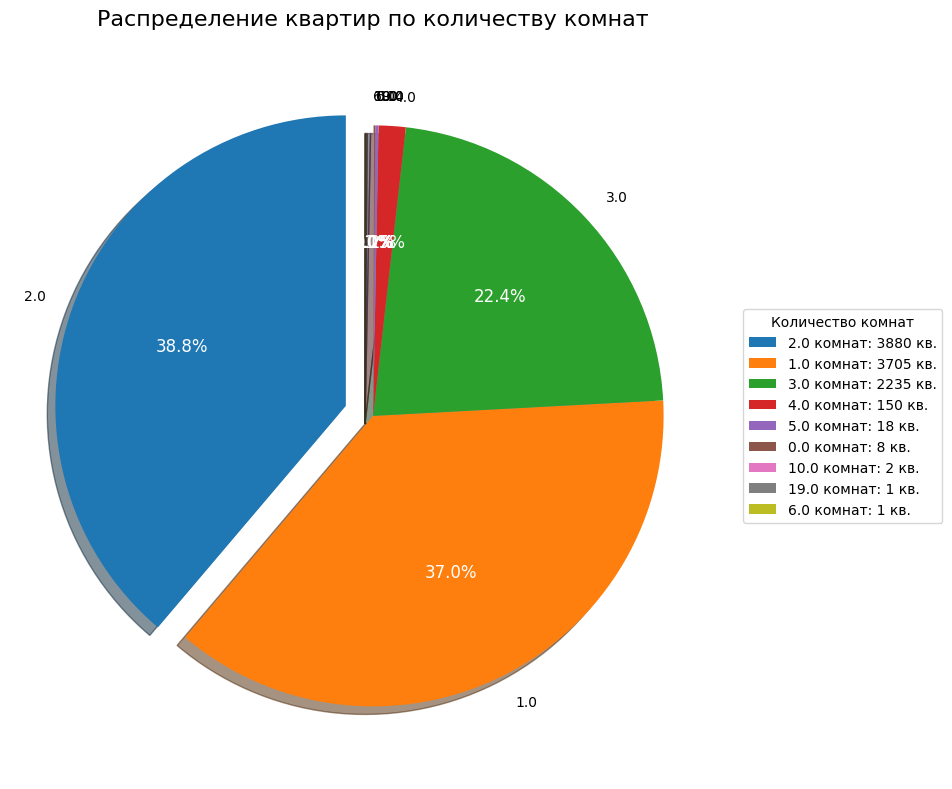

In [ ]:
import matplotlib.pyplot as plt

rooms_count = data['Rooms'].value_counts()

max_index = rooms_count.idxmax()
explode = [0.1 if i == max_index else 0 for i in rooms_count.index]

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(rooms_count.values,
                                   labels=rooms_count.index,
                                   autopct='%1.1f%%',
                                   explode=explode,
                                   startangle=90,
                                   shadow=True)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.title('Распределение квартир по количеству комнат', fontsize=16, pad=20)

plt.legend(wedges,
           [f'{label} комнат: {value} кв.' for label, value in zip(rooms_count.index, rooms_count.values)],
           title="Количество комнат",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

18. Постройте гистограмму по целевой переменной Price. Оцените визуально, по какой цене продаётся наибольшее количество квартир.

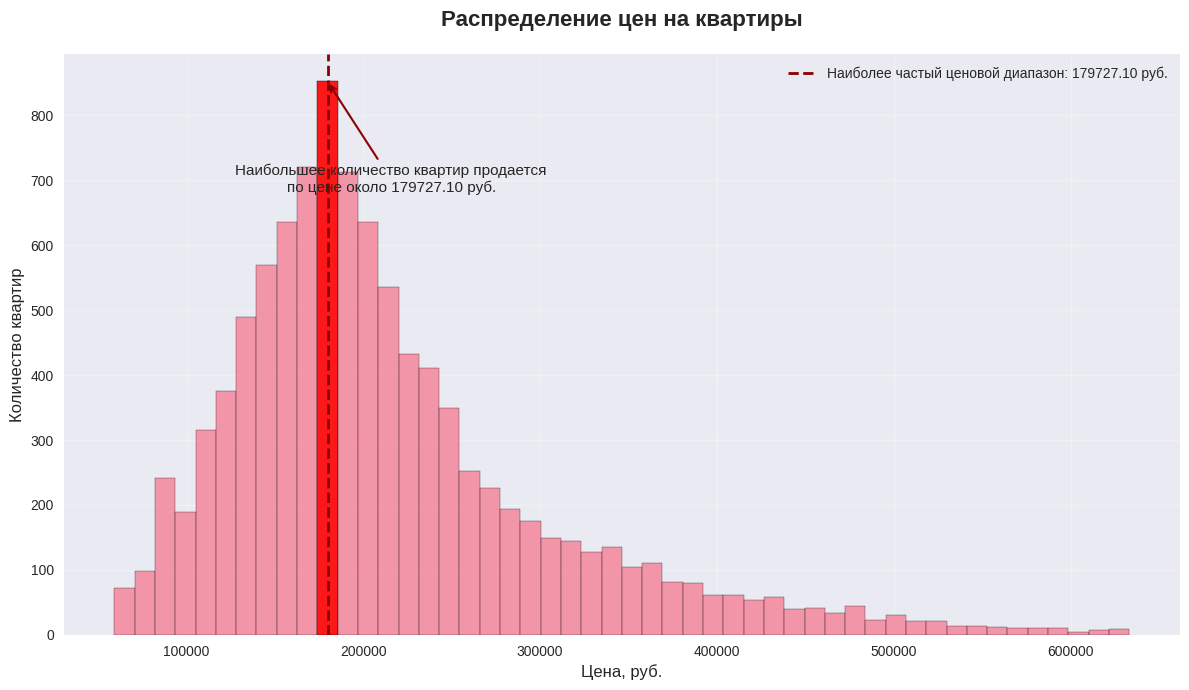

Модальный интервал цен: 179727.10 руб.
Количество квартир в этом интервале: 852
Общее количество квартир в выборке: 10000


In [ ]:
import seaborn as sns

data = pd.read_csv('/content/data.csv')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.figure(figsize=(12, 7))
n, bins, patches = plt.hist(data['Price'], bins=50, edgecolor='black', alpha=0.7)

max_bin_index = n.argmax()
patches[max_bin_index].set_facecolor('red')
patches[max_bin_index].set_alpha(0.9)

modal_interval = (bins[max_bin_index] + bins[max_bin_index+1]) / 2
plt.axvline(modal_interval, color='darkred', linestyle='--', linewidth=2,
            label=f'Наиболее частый ценовой диапазон: {modal_interval:.2f} руб.')

plt.title('Распределение цен на квартиры', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Цена, руб.', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.annotate(f'Наибольшее количество квартир продается\nпо цене около {modal_interval:.2f} руб.',
             xy=(modal_interval, n.max()),
             xytext=(modal_interval*1.2, n.max()*0.8),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
             fontsize=11, ha='center')

plt.tight_layout()
plt.show()

print(f"Модальный интервал цен: {modal_interval:.2f} руб.")
print(f"Количество квартир в этом интервале: {n.max():.0f}")
print(f"Общее количество квартир в выборке: {len(data)}")

19. Постройте диаграммы рассеяния для признаков Rooms, Square, HouseFloor, HouseYear в зависимости от целевой переменной Price в одной области figure. Оцените визуально, есть ли среди них такие, на которых разброс точек близок к линейной функции.

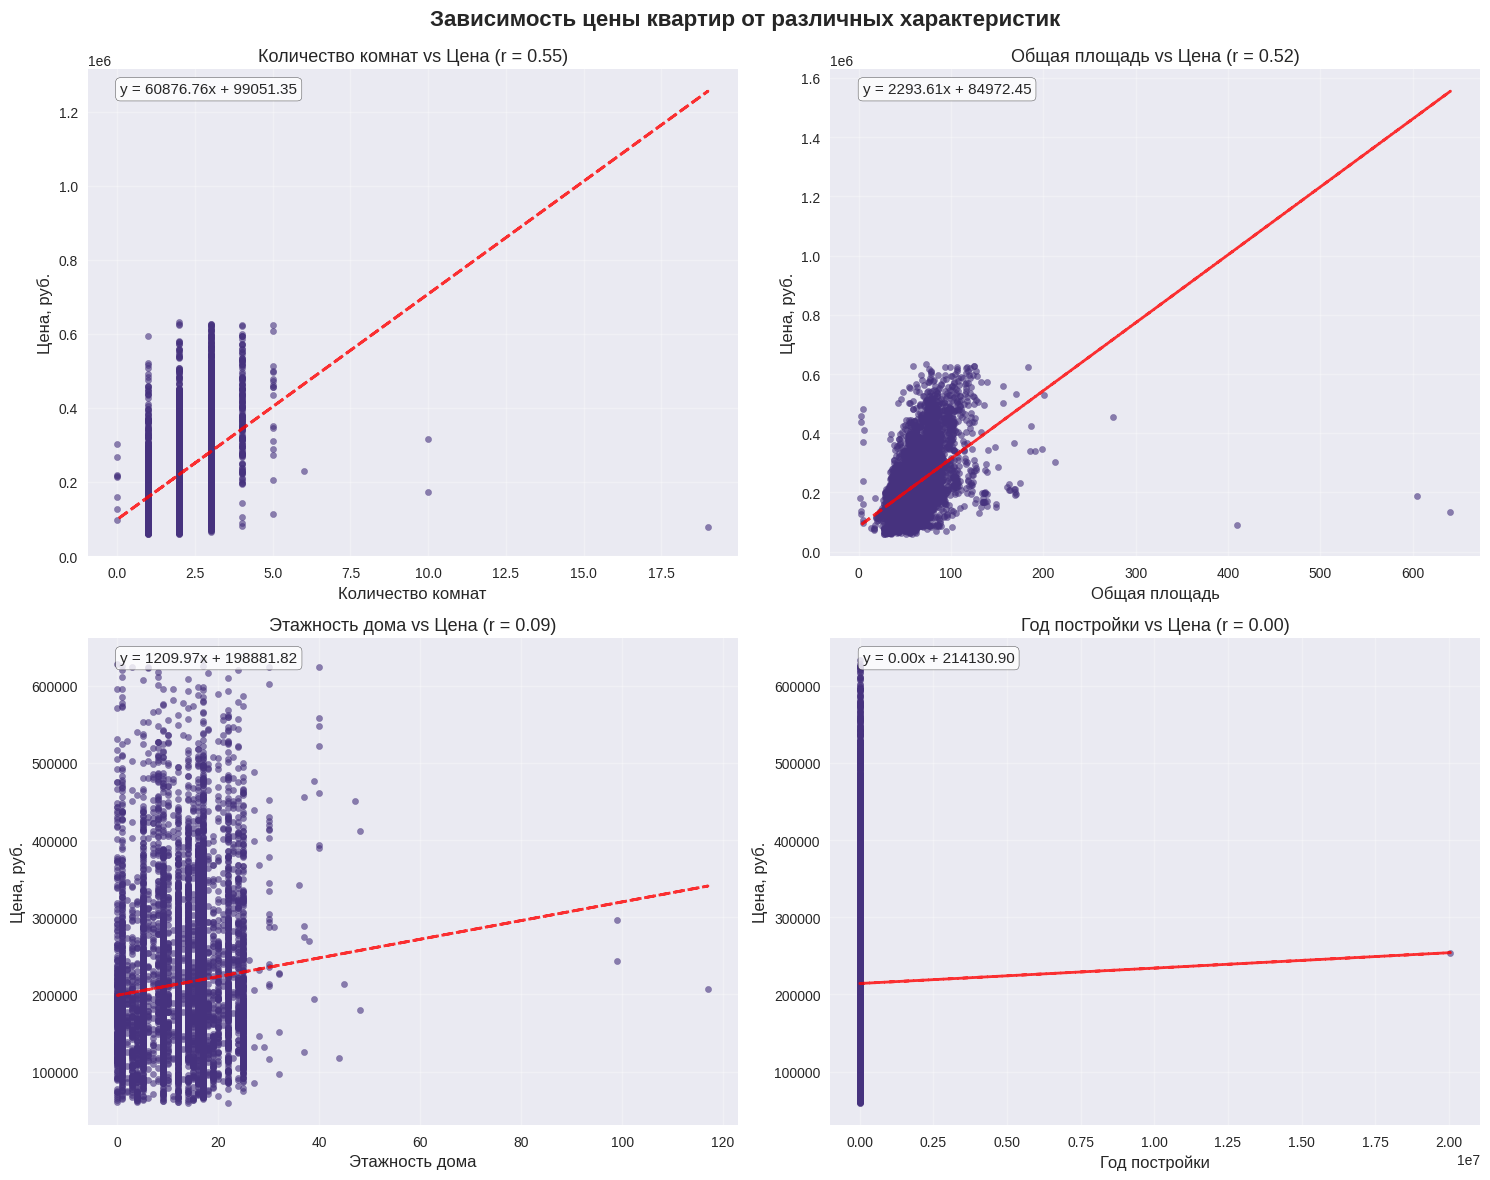

Анализ линейности зависимостей:
Количество комнат: коэффициент корреляции = 0.550
  → Умеренная линейная зависимость
Общая площадь: коэффициент корреляции = 0.520
  → Умеренная линейная зависимость
Этажность дома: коэффициент корреляции = 0.088
  → Линейная зависимость отсутствует или очень слабая
Год постройки: коэффициент корреляции = 0.004
  → Линейная зависимость отсутствует или очень слабая


In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Зависимость цены квартир от различных характеристик', fontsize=16, fontweight='bold')

features = ['Rooms', 'Square', 'HouseFloor', 'HouseYear']
titles = ['Количество комнат', 'Общая площадь', 'Этажность дома', 'Год постройки']

for i, (feature, title) in enumerate(zip(features, titles)):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    scatter = ax.scatter(data[feature], data['Price'], alpha=0.6, s=20)

    z = np.polyfit(data[feature], data['Price'], 1)
    p = np.poly1d(z)
    ax.plot(data[feature], p(data[feature]), "r--", alpha=0.8, linewidth=2)

    correlation = data[feature].corr(data['Price'])

    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel('Цена, руб.', fontsize=12)
    ax.set_title(f'{title} vs Цена (r = {correlation:.2f})', fontsize=13)
    ax.grid(True, alpha=0.3)

    equation = f'y = {z[0]:.2f}x + {z[1]:.2f}'
    ax.annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

print("Анализ линейности зависимостей:")
for feature, title in zip(features, titles):
    correlation = data[feature].corr(data['Price'])
    print(f"{title}: коэффициент корреляции = {correlation:.3f}")
    if abs(correlation) > 0.7:
        print("  → Сильная линейная зависимость")
    elif abs(correlation) > 0.5:
        print("  → Умеренная линейная зависимость")
    elif abs(correlation) > 0.3:
        print("  → Слабая линейная зависимость")
    else:
        print("  → Линейная зависимость отсутствует или очень слабая")

20. Постройте ядерную оценку плотности целевой переменной Price. Оцените визуально, напоминает ли полученный график нормальное распределение. Постройте двумерную ядерную оценку плотности для целевой переменной Price и признака HouseFloor, затем оцените визуально на каких этажах и по какой цене продаётся основная масса квартир.

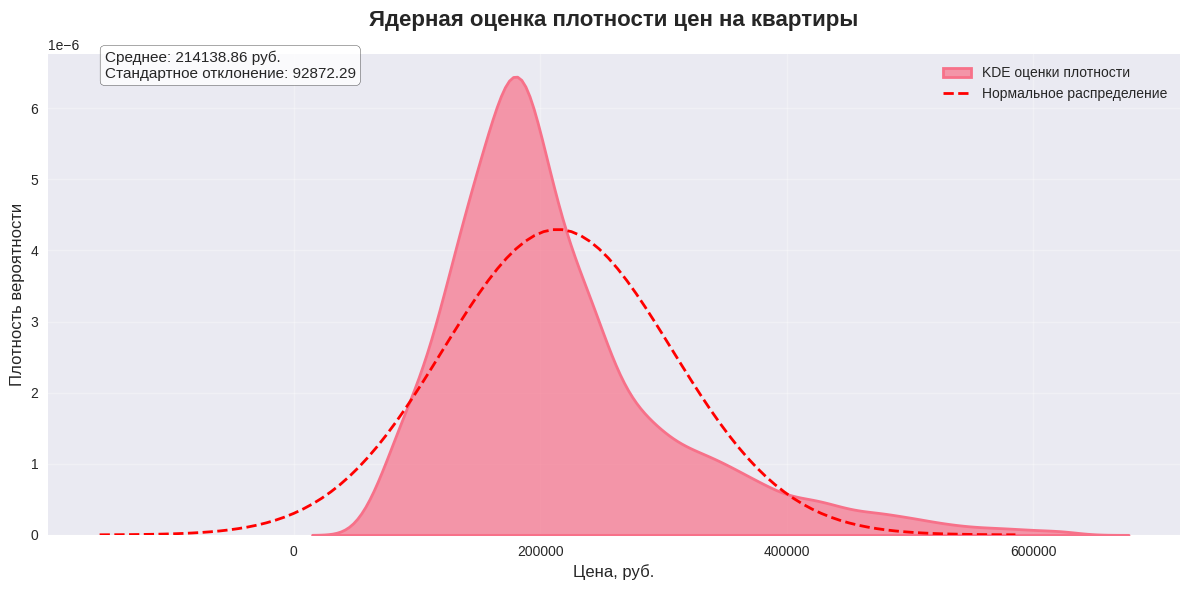

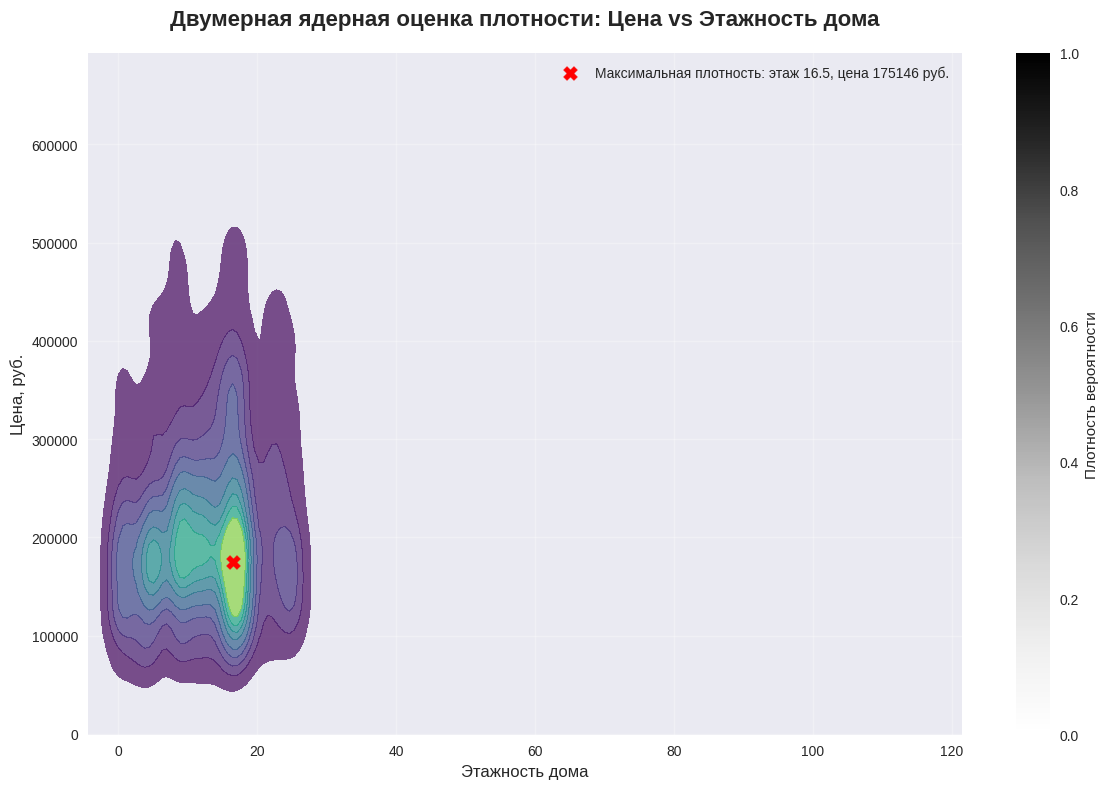

Анализ распределения цен:
Средняя цена: 214138.86 руб.
Медианная цена: 192269.64 руб.
Стандартное отклонение: 92872.29 руб.
Эксцесс: 2.25
Асимметрия: 1.37

Анализ концентрации квартир по этажам и ценам:
Основная масса квартир продается на этажах: 17.0
Средняя этажность: 12.6
Медианная этажность: 13.0


In [ ]:
from scipy import stats

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.figure(figsize=(12, 6))

sns.kdeplot(data['Price'], fill=True, alpha=0.7, linewidth=2, label='KDE оценки плотности')

mu, std = data['Price'].mean(), data['Price'].std()
x = np.linspace(mu - 4*std, mu + 4*std, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label='Нормальное распределение')

plt.title('Ядерная оценка плотности цен на квартиры', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Цена, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.annotate(f'Среднее: {mu:.2f} руб.\nСтандартное отклонение: {std:.2f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
             fontsize=11)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))

sns.kdeplot(data=data, x='HouseFloor', y='Price', fill=True, cmap='viridis', alpha=0.7)

from scipy import stats
kde = stats.gaussian_kde([data['HouseFloor'], data['Price']])
xi, yi = np.mgrid[data['HouseFloor'].min():data['HouseFloor'].max():100j,
                 data['Price'].min():data['Price'].max():100j]
zi = kde(np.vstack([xi.flatten(), yi.flatten()]))

max_density_idx = np.argmax(zi)
max_x, max_y = xi.flatten()[max_density_idx], yi.flatten()[max_density_idx]

plt.scatter(max_x, max_y, color='red', s=100, marker='X',
           label=f'Максимальная плотность: этаж {max_x:.1f}, цена {max_y:.0f} руб.')

plt.title('Двумерная ядерная оценка плотности: Цена vs Этажность дома',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Этажность дома', fontsize=12)
plt.ylabel('Цена, руб.', fontsize=12)
plt.colorbar(label='Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Анализ распределения цен:")
print(f"Средняя цена: {mu:.2f} руб.")
print(f"Медианная цена: {data['Price'].median():.2f} руб.")
print(f"Стандартное отклонение: {std:.2f} руб.")
print(f"Эксцесс: {stats.kurtosis(data['Price']):.2f}")
print(f"Асимметрия: {stats.skew(data['Price']):.2f}")

print("\nАнализ концентрации квартир по этажам и ценам:")
print(f"Основная масса квартир продается на этажах: {data['HouseFloor'].mode().values[0]}")
print(f"Средняя этажность: {data['HouseFloor'].mean():.1f}")
print(f"Медианная этажность: {data['HouseFloor'].median():.1f}")

21. Постройте ящиковую диаграмму признака Square. Оцените визуально имеются ли выбросы, и, если да, то начиная с какого размера площади значение признака можно считать выбросом.

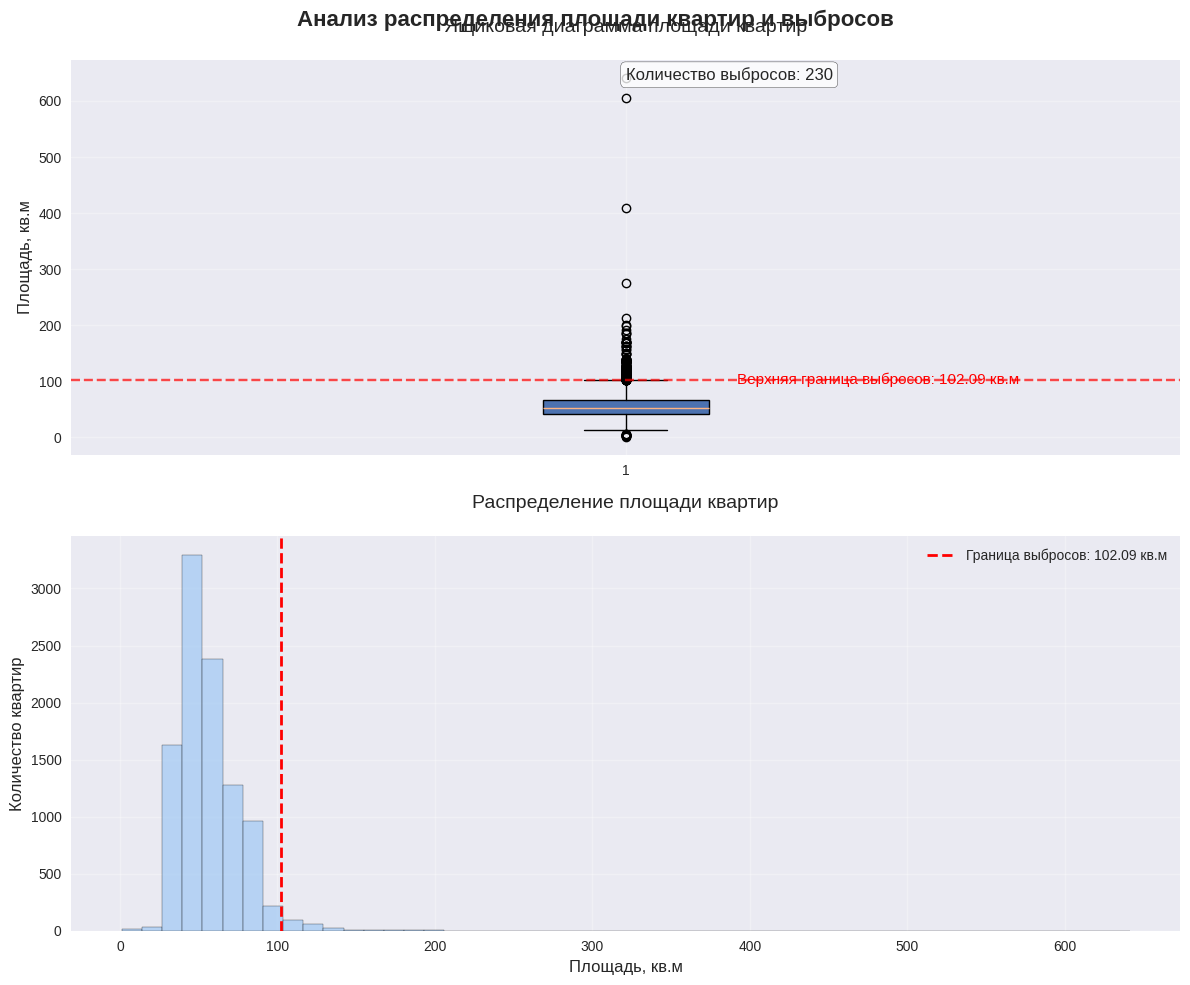

Анализ выбросов в признаке Square:
Первая квартиль (Q1): 41.77 кв.м
Третья квартиль (Q3): 65.90 кв.м
Межквартильный размах (IQR): 24.13 кв.м
Нижняя граница выбросов: 5.59 кв.м
Верхняя граница выбросов: 102.09 кв.м
Количество выбросов: 230
Процент выбросов: 2.30%
Минимальная площадь среди выбросов: 102.12 кв.м
Максимальная площадь среди выбросов: 641.07 кв.м


In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("pastel")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Анализ распределения площади квартир и выбросов', fontsize=16, fontweight='bold')

boxplot = ax1.boxplot(data['Square'], vert=True, patch_artist=True)
ax1.set_title('Ящиковая диаграмма площади квартир', fontsize=14, pad=20)
ax1.set_ylabel('Площадь, кв.м', fontsize=12)
ax1.grid(True, alpha=0.3)

Q1 = data['Square'].quantile(0.25)
Q3 = data['Square'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ax1.axhline(y=upper_bound, color='r', linestyle='--', alpha=0.7)
ax1.text(1.1, upper_bound, f'Верхняя граница выбросов: {upper_bound:.2f} кв.м',
         va='center', ha='left', fontsize=11, color='red')

outliers = data[data['Square'] > upper_bound]
ax1.text(0.5, 0.95, f'Количество выбросов: {len(outliers)}',
         transform=ax1.transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

ax2.hist(data['Square'], bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=upper_bound, color='r', linestyle='--', linewidth=2,
           label=f'Граница выбросов: {upper_bound:.2f} кв.м')
ax2.set_title('Распределение площади квартир', fontsize=14, pad=20)
ax2.set_xlabel('Площадь, кв.м', fontsize=12)
ax2.set_ylabel('Количество квартир', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

print("Анализ выбросов в признаке Square:")
print(f"Первая квартиль (Q1): {Q1:.2f} кв.м")
print(f"Третья квартиль (Q3): {Q3:.2f} кв.м")
print(f"Межквартильный размах (IQR): {IQR:.2f} кв.м")
print(f"Нижняя граница выбросов: {lower_bound:.2f} кв.м")
print(f"Верхняя граница выбросов: {upper_bound:.2f} кв.м")
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(data)*100:.2f}%")
print(f"Минимальная площадь среди выбросов: {outliers['Square'].min():.2f} кв.м")
print(f"Максимальная площадь среди выбросов: {outliers['Square'].max():.2f} кв.м")

22. При помощи сетки графиков PairGrid визуализируйте попарные отношения признаков Rooms, Square, HouseFloor, HouseYear, Price следующим образом: на диагонали - гистограммы, под диагональю - ядерные оценки плотности, над диагональю - диаграммы рассеяния. По результатам визуализации сделайте выводы.

<Figure size 1500x1500 with 0 Axes>

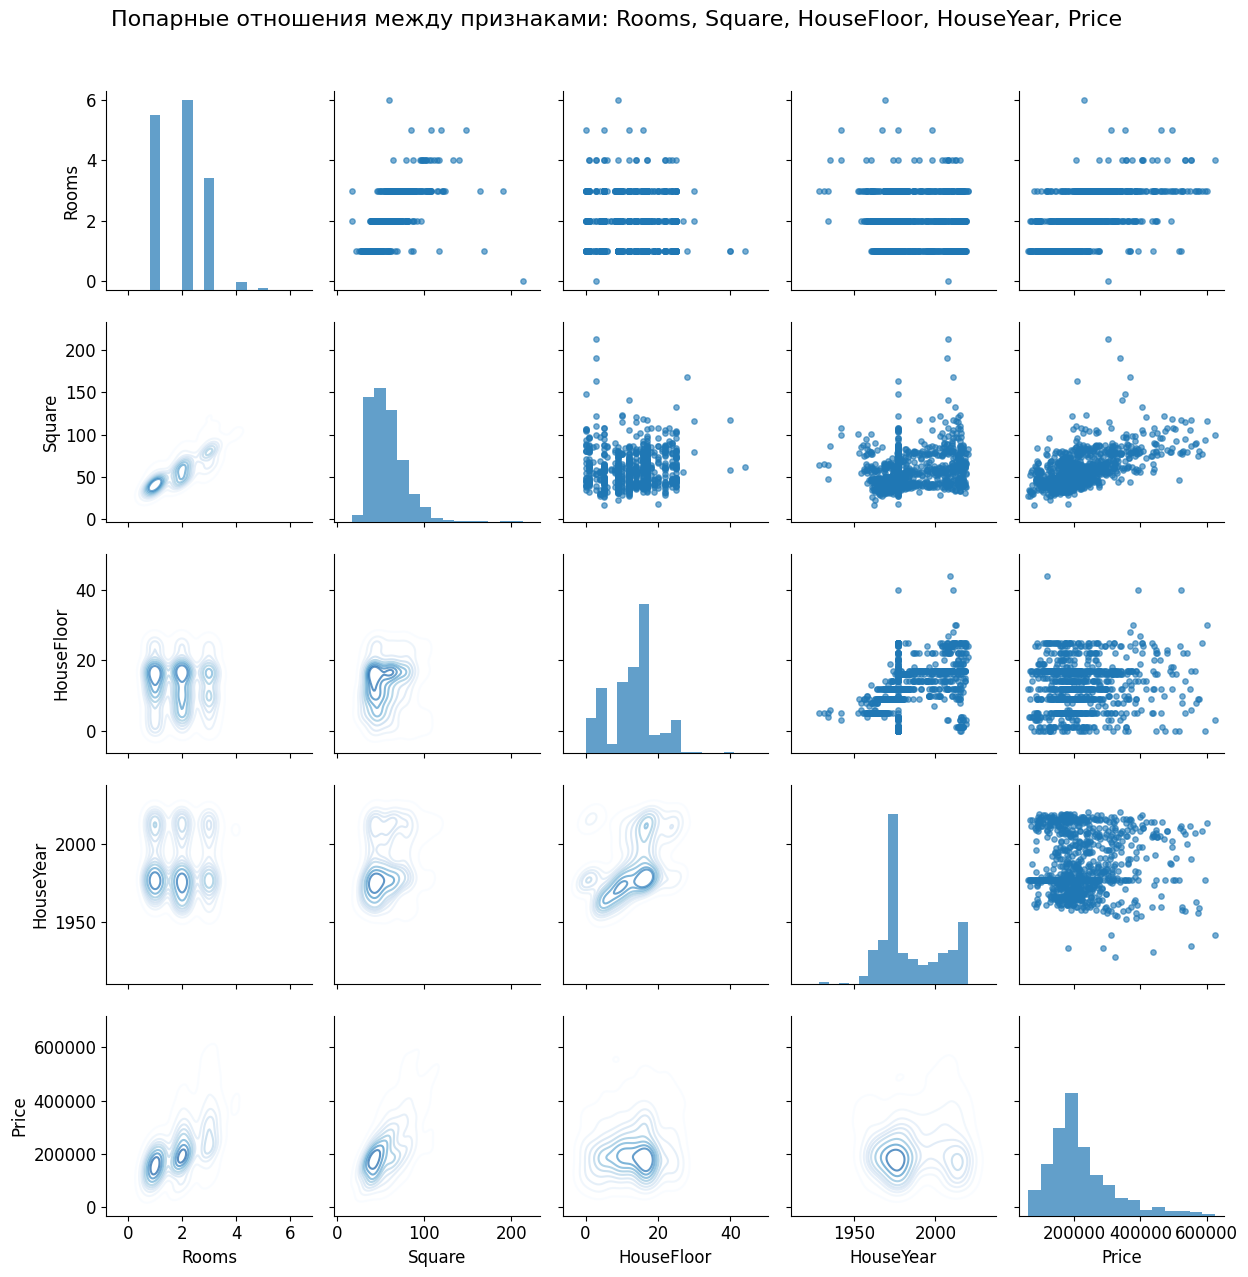

Матрица корреляций:
            Rooms  Square  HouseFloor  HouseYear  Price
Rooms       1.000   0.663      -0.029     -0.011  0.550
Square      0.663   1.000       0.082     -0.009  0.520
HouseFloor -0.029   0.082       1.000     -0.001  0.088
HouseYear  -0.011  -0.009      -0.001      1.000  0.004
Price       0.550   0.520       0.088      0.004  1.000


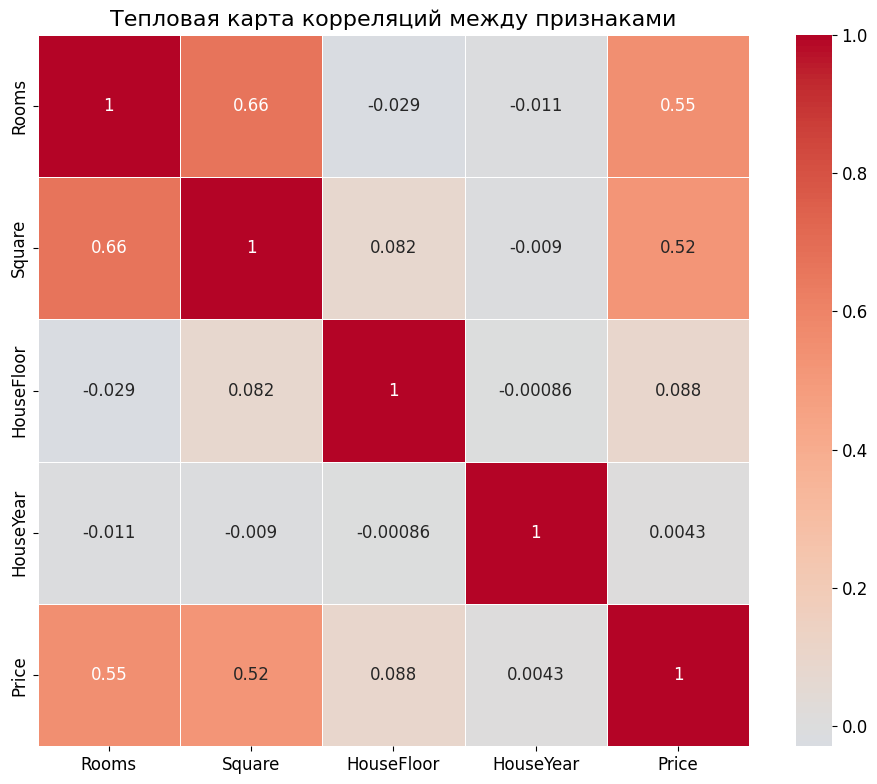

In [ ]:
features = ['Rooms', 'Square', 'HouseFloor', 'HouseYear', 'Price']
df_selected = data[features].dropna()

plt.figure(figsize=(15, 15))
g = sns.PairGrid(df_selected.sample(min(1000, len(df_selected)), random_state=42))

g.map_upper(plt.scatter, alpha=0.6, s=15)

g.map_diag(plt.hist, alpha=0.7, bins=15)

g.map_lower(sns.kdeplot, cmap='Blues', alpha=0.7)

plt.suptitle('Попарные отношения между признаками: Rooms, Square, HouseFloor, HouseYear, Price',
             fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print("Матрица корреляций:")
correlation_matrix = df_selected.corr()
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций между признаками', fontsize=16)
plt.tight_layout()
plt.show()

23. Постройте тепловую карту матрицы корреляции (df.corr()) признаков Rooms, Square, HouseFloor, HouseYear, Price. По ней определите, какие признаки являются зависимыми (у таких признаков коэффициент корреляции близок к единице).

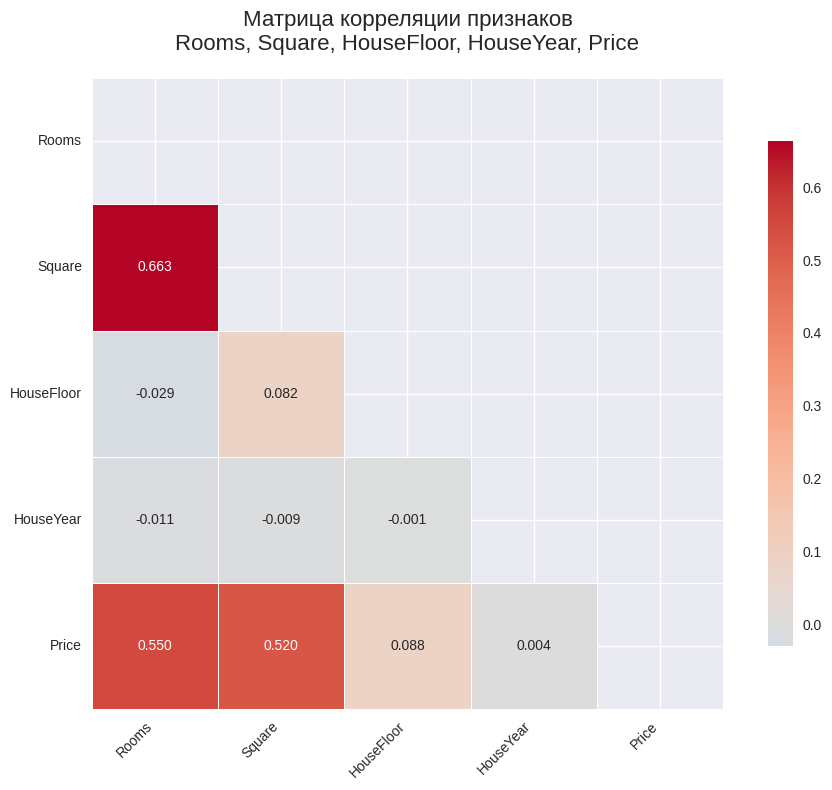

Анализ корреляционных зависимостей:

Сильные корреляции (|r| > 0.5):
Rooms & Square: 0.663 (положительная)
Rooms & Price: 0.550 (положительная)
Square & Price: 0.520 (положительная)

Корреляции, близкие к 1 (сильная зависимость):


In [ ]:
features = ['Rooms', 'Square', 'HouseFloor', 'HouseYear', 'Price']
df_selected = data[features]

correlation_matrix = df_selected.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=True,
                      cmap='coolwarm',
                      center=0,
                      square=True,
                      linewidths=0.5,
                      fmt='.3f',
                      cbar_kws={'shrink': 0.8})

plt.title('Матрица корреляции признаков\nRooms, Square, HouseFloor, HouseYear, Price',
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            heatmap.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

plt.tight_layout()
plt.show()

print("Анализ корреляционных зависимостей:")
print("=" * 50)

strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_correlations.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

print("\nСильные корреляции (|r| > 0.5):")
for feat1, feat2, corr in strong_correlations:
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"{feat1} & {feat2}: {corr:.3f} ({direction})")

print("\nКорреляции, близкие к 1 (сильная зависимость):")
for feat1, feat2, corr in strong_correlations:
    if abs(corr) > 0.7:
        print(f"{feat1} & {feat2}: {corr:.3f}")

1. Загрузите данные по вариантам в ноутбук.

In [ ]:
import pandas as pd

file_path = 'Вариант 3.xlsx'
df = pd.read_excel(
    file_path,
    sheet_name='Выполнение заданий',
    skiprows=2,
    usecols='A:K',
    dtype={'Класс': str}
)

df = df.dropna(how='all')

print(df.head())

     №  № школы Класс Пол  Номер варианта    Задания с кратким ответом  \
0  1.0    152.0    11   М           333.0  ----001---00---000--1-+0---   
1  2.0    140.0    12   Ж           332.0  ----100---01-+-000--0--1---   
2  3.0    137.0    11   М           328.0  --+-010---00---101--0--1---   
3  4.0    148.0    11   М           333.0  -+--000--+01---100--0--1---   
4  5.0    153.0    11   Ж           333.0  -+--100---00---100-+0--1---   

  Задания с развёрнутым ответом Устная часть  Первичный балл  Балл  \
0          0(3)0(3)0(3)0(3)0(3)          NaN             3.0  10.0   
1          0(3)0(3)0(3)0(3)0(3)          NaN             4.0  14.0   
2          0(3)0(3)0(3)0(3)0(3)          NaN             5.0  17.0   
3          0(3)0(3)0(3)0(3)0(3)          NaN             5.0  17.0   
4          0(3)0(3)0(3)0(3)0(3)          NaN             5.0  17.0   

   Минимальный балл  
0              36.0  
1              36.0  
2              36.0  
3              36.0  
4              36.0  


2. Сделайте описательную статистику полученных данных.

In [ ]:
print("Размерность данных:", df.shape)
print("\nИнформация о данных:")
df.info()

print("\nПропущенные значения:")
print(df.isnull().sum())

print("\nОписательная статистика числовых колонок:")
print(df.describe())

print("\nСтатистика для нечисловых колонок:")
print(df.describe(include=['object']))

categorical_cols = ['№ школы', 'Класс', 'Пол', 'Номер варианта']
for col in categorical_cols:
    print(f"\nУникальные значения в колонке {col}:")
    print(df[col].value_counts())

Размерность данных: (1181, 11)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   №                              1180 non-null   float64
 1   № школы                        1180 non-null   float64
 2   Класс                          1180 non-null   object 
 3   Пол                            1180 non-null   object 
 4   Номер варианта                 1180 non-null   float64
 5   Задания с кратким ответом      1180 non-null   object 
 6   Задания с развёрнутым ответом  1180 non-null   object 
 7   Устная часть                   1 non-null      object 
 8   Первичный балл                 1180 non-null   float64
 9   Балл                           1181 non-null   float64
 10  Минимальный балл               1180 non-null   float64
dtypes: float64(6), object(5)
memory usage: 101.6+ KB

Пропу

3. Найдите процент учащихся, выполнивших работу ниже среднего.

In [ ]:
mean_score = df['Балл'].mean()
print(f"Средний балл: {mean_score:.2f}")

below_average = df[df['Балл'] < mean_score].shape[0]
total_students = df.shape[0]

percentage_below_average = (below_average / total_students) * 100

print(f"Количество учащихся с баллом ниже среднего: {below_average}")
print(f"Общее количество учащихся: {total_students}")
print(f"Процент учащихся с баллом ниже среднего: {percentage_below_average:.2f}%")

Средний балл: 52.05
Количество учащихся с баллом ниже среднего: 664
Общее количество учащихся: 1181
Процент учащихся с баллом ниже среднего: 56.22%


4. Найти процент учащихся не сдавших экзамен.

In [ ]:
min_pass_score = df['Минимальный балл'].iloc[0]

failed_count = df[df['Балл'] < min_pass_score].shape[0]
total_students = df.shape[0]

percentage_failed = (failed_count / total_students) * 100

print(f"Минимальный балл для сдачи: {min_pass_score}")
print(f"Количество учащихся, не сдавших экзамен: {failed_count}")
print(f"Общее количество учащихся: {total_students}")
print(f"Процент учащихся, не сдавших экзамен: {percentage_failed:.2f}%")

Минимальный балл для сдачи: 36.0
Количество учащихся, не сдавших экзамен: 91
Общее количество учащихся: 1181
Процент учащихся, не сдавших экзамен: 7.71%


5. Постройте круговую диаграмму, показывающую распределение сдавших и не сдавших экзамен.

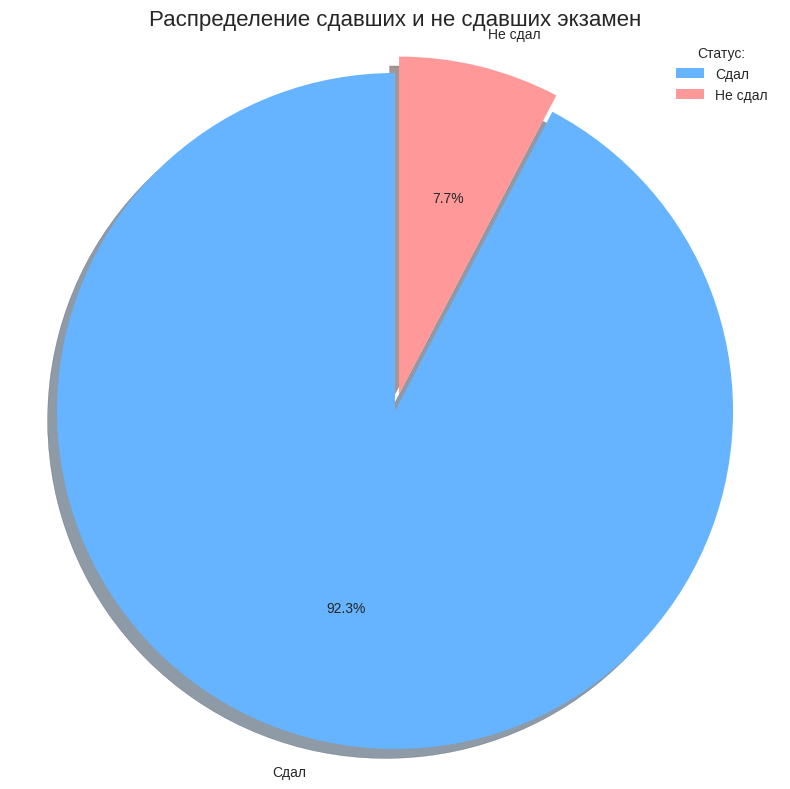

Количество учащихся по статусу:
Статус
Сдал       1090
Не сдал      91
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

df['Статус'] = df['Балл'].apply(lambda x: 'Сдал' if x >= 36 else 'Не сдал')

status_counts = df['Статус'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True)

plt.title('Распределение сдавших и не сдавших экзамен', fontsize=16)
plt.axis('equal')

plt.legend(title="Статус:", loc="best")

plt.tight_layout()
plt.show()

print("Количество учащихся по статусу:")
print(status_counts)

6. Постройте ядерную оценку плотности распределению баллов за экзамен.

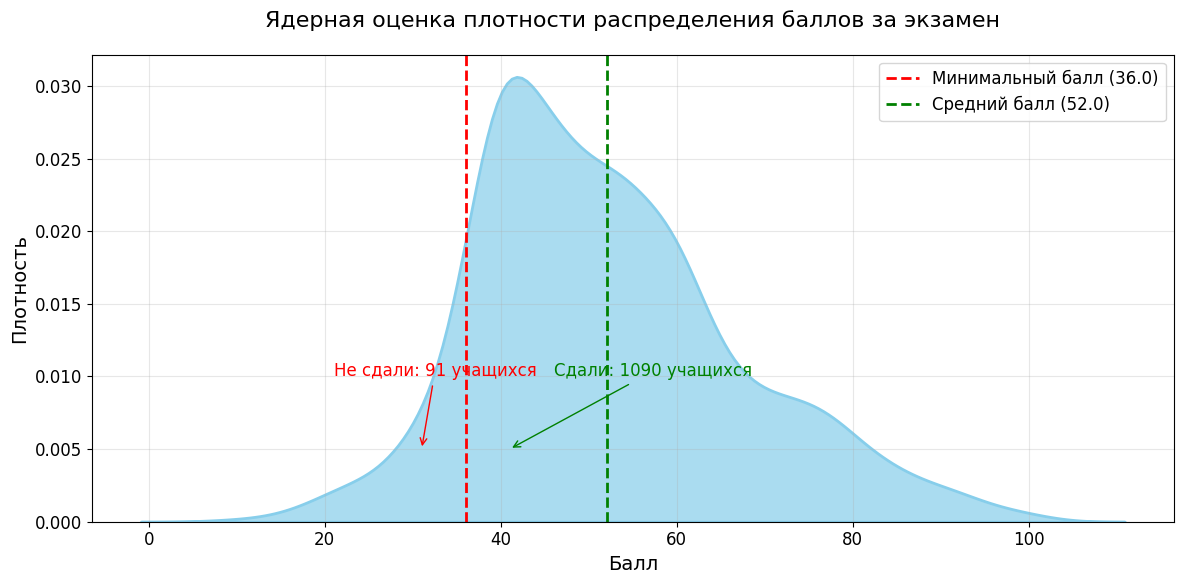

Дополнительная статистика:
Минимальный балл: 10.0
Максимальный балл: 100.0
Медианный балл: 49.0
Стандартное отклонение: 14.96


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x='Балл', fill=True, alpha=0.7, color='skyblue', linewidth=2)

min_pass_score = df['Минимальный балл'].iloc[0]
plt.axvline(x=min_pass_score, color='red', linestyle='--', linewidth=2,
            label=f'Минимальный балл ({min_pass_score})')

mean_score = df['Балл'].mean()
plt.axvline(x=mean_score, color='green', linestyle='--', linewidth=2,
            label=f'Средний балл ({mean_score:.1f})')

plt.title('Ядерная оценка плотности распределения баллов за экзамен', fontsize=16, pad=20)
plt.xlabel('Балл', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.annotate(f'Не сдали: {df[df["Балл"] < min_pass_score].shape[0]} учащихся',
             xy=(min_pass_score-5, 0.005),
             xytext=(min_pass_score-15, 0.01),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=12, color='red')

plt.annotate(f'Сдали: {df[df["Балл"] >= min_pass_score].shape[0]} учащихся',
             xy=(min_pass_score+5, 0.005),
             xytext=(min_pass_score+10, 0.01),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=12, color='green')

plt.tight_layout()
plt.show()

print("Дополнительная статистика:")
print(f"Минимальный балл: {df['Балл'].min()}")
print(f"Максимальный балл: {df['Балл'].max()}")
print(f"Медианный балл: {df['Балл'].median()}")
print(f"Стандартное отклонение: {df['Балл'].std():.2f}")

7. Найдите процентное соотношение учащихся, сдавших экзамен на «отлично», «хорошо», «удовлетворительно», «неудовлетворительно».

Границы оценок:
Отлично: 52-61 баллов
Хорошо: 43-51 баллов
Удовлетворительно: 36-42 баллов
Неудовлетворительно: ниже 36 баллов

Распределение оценок:
Отлично: 549 учащихся (46.49%)
Хорошо: 256 учащихся (21.68%)
Удовлетворительно: 285 учащихся (24.13%)
Неудовлетворительно: 91 учащихся (7.71%)


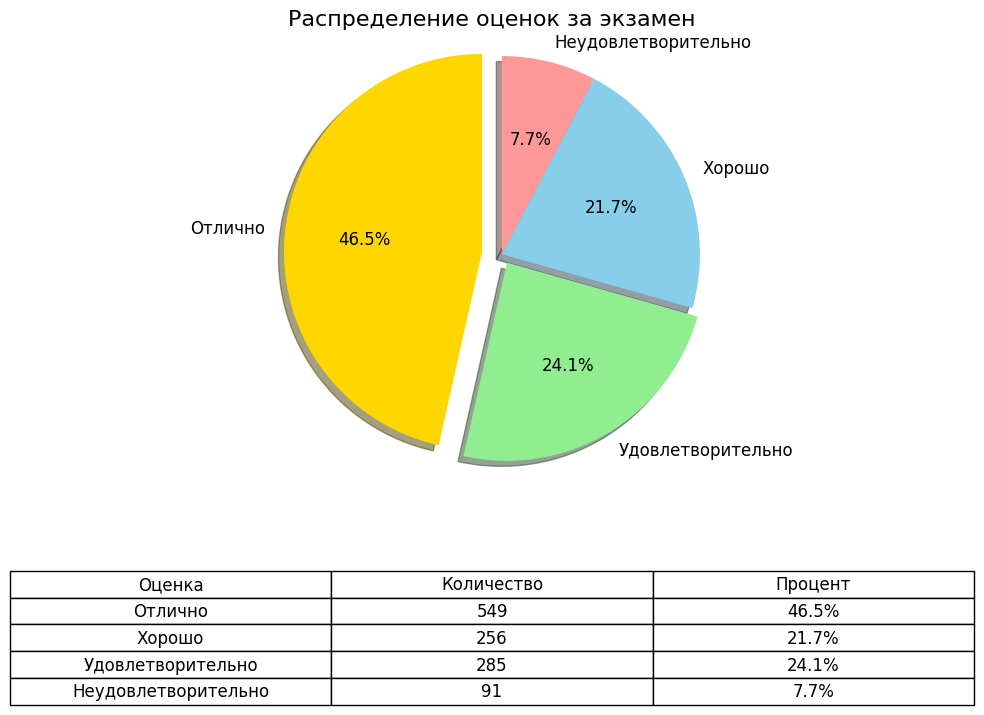

In [ ]:
max_score = 61
min_pass_score = 36

excellent_min = round(max_score * 0.85)
good_min = round(max_score * 0.70)
satisfactory_min = min_pass_score

print(f"Границы оценок:")
print(f"Отлично: {excellent_min}-{max_score} баллов")
print(f"Хорошо: {good_min}-{excellent_min-1} баллов")
print(f"Удовлетворительно: {satisfactory_min}-{good_min-1} баллов")
print(f"Неудовлетворительно: ниже {satisfactory_min} баллов")

def get_grade(score):
    if score >= excellent_min:
        return "Отлично"
    elif score >= good_min:
        return "Хорошо"
    elif score >= satisfactory_min:
        return "Удовлетворительно"
    else:
        return "Неудовлетворительно"

df['Оценка'] = df['Балл'].apply(get_grade)

grade_distribution = df['Оценка'].value_counts()
total_students = len(df)

percentage_distribution = (grade_distribution / total_students) * 100

print("\nРаспределение оценок:")
for grade in ["Отлично", "Хорошо", "Удовлетворительно", "Неудовлетворительно"]:
    count = grade_distribution.get(grade, 0)
    percentage = percentage_distribution.get(grade, 0)
    print(f"{grade}: {count} учащихся ({percentage:.2f}%)")

plt.figure(figsize=(10, 7))
colors = ['#FFD700', '#90EE90', '#87CEEB', '#FF9999']
explode = (0.1, 0.05, 0, 0)

plt.pie(grade_distribution.values,
        labels=grade_distribution.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True)

plt.title('Распределение оценок за экзамен', fontsize=16)
plt.axis('equal')

table_data = []
for grade in ["Отлично", "Хорошо", "Удовлетворительно", "Неудовлетворительно"]:
    count = grade_distribution.get(grade, 0)
    percentage = percentage_distribution.get(grade, 0)
    table_data.append([grade, count, f"{percentage:.1f}%"])

plt.table(cellText=table_data,
          colLabels=['Оценка', 'Количество', 'Процент'],
          cellLoc='center',
          loc='bottom',
          bbox=[0, -0.5, 1, 0.3])

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

8. Какое процентное соотношение юношей и девушек писало данный экзамен?

Распределение участников экзамена по полу:
Юноши: 810 учащихся (68.59%)
Девушки: 370 учащихся (31.33%)


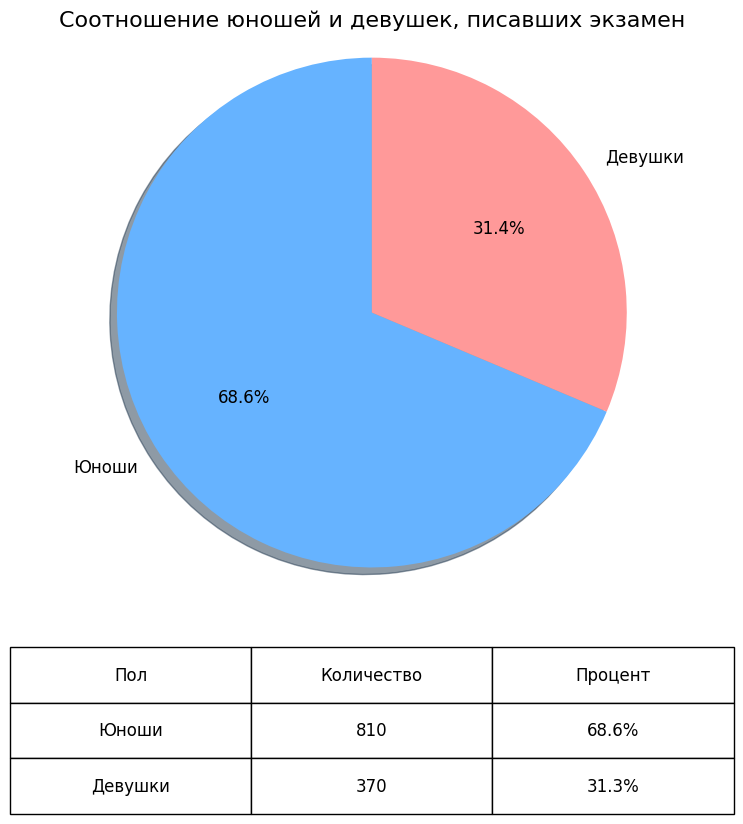


Средний балл по полу:
Девушки: 53.21 баллов
Юноши: 51.51 баллов

Процент сдавших экзамен по полу:
Девушки: 93.24%
Юноши: 91.85%


In [ ]:
gender_distribution = df['Пол'].value_counts()
total_students = len(df)

percentage_distribution = (gender_distribution / total_students) * 100

print("Распределение участников экзамена по полу:")
print(f"Юноши: {gender_distribution.get('М', 0)} учащихся ({percentage_distribution.get('М', 0):.2f}%)")
print(f"Девушки: {gender_distribution.get('Ж', 0)} учащихся ({percentage_distribution.get('Ж', 0):.2f}%)")

plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
labels = ['Юноши', 'Девушки']

plt.pie(gender_distribution.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        shadow=True)

plt.title('Соотношение юношей и девушек, писавших экзамен', fontsize=16)
plt.axis('equal')

table_data = [
    ['Юноши', gender_distribution.get('М', 0), f"{percentage_distribution.get('М', 0):.1f}%"],
    ['Девушки', gender_distribution.get('Ж', 0), f"{percentage_distribution.get('Ж', 0):.1f}%"]
]

plt.table(cellText=table_data,
          colLabels=['Пол', 'Количество', 'Процент'],
          cellLoc='center',
          loc='bottom',
          bbox=[0, -0.4, 1, 0.3])

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

print("\nСредний балл по полу:")
mean_scores_by_gender = df.groupby('Пол')['Балл'].mean()
for gender, mean_score in mean_scores_by_gender.items():
    gender_name = 'Юноши' if gender == 'М' else 'Девушки'
    print(f"{gender_name}: {mean_score:.2f} баллов")

passed_by_gender = df[df['Балл'] >= 36].groupby('Пол').size()
passed_percentage = (passed_by_gender / gender_distribution) * 100

print("\nПроцент сдавших экзамен по полу:")
for gender, percentage in passed_percentage.items():
    gender_name = 'Юноши' if gender == 'М' else 'Девушки'
    print(f"{gender_name}: {percentage:.2f}%")

9. Сколько школ принимало участие в экзамене?

Количество школ, принимавших участие в экзамене: 19

Топ-10 школ по количеству участников:
№ школы
148.0    214
152.0    170
140.0    135
153.0    129
137.0     72
147.0     67
111.0     63
144.0     61
126.0     56
133.0     49
Name: count, dtype: int64


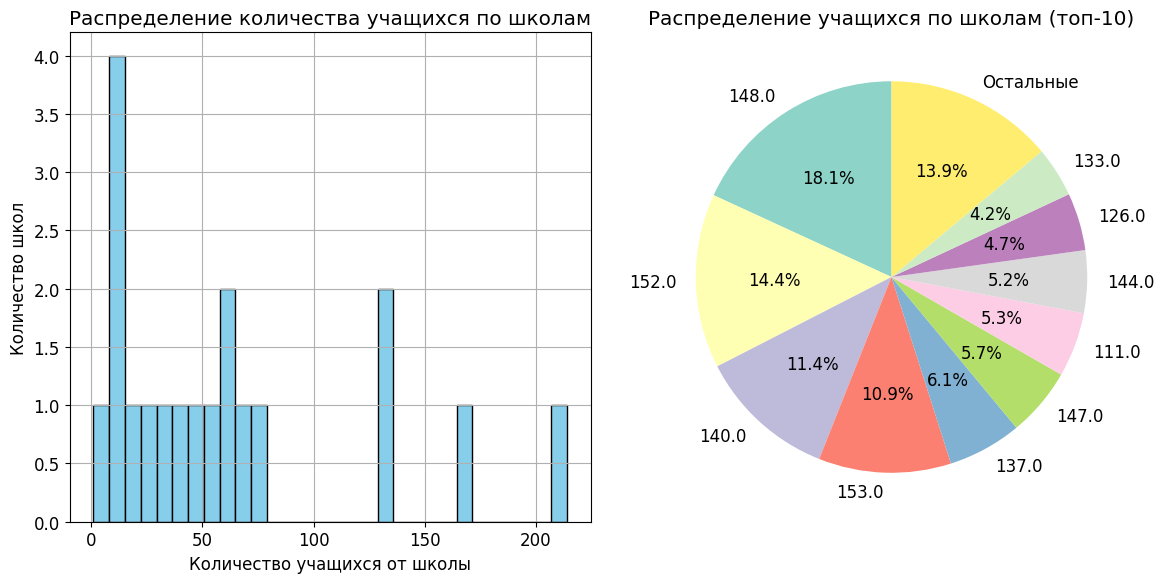


Общая статистика по школам:
Максимальное количество учащихся от одной школы: 214
Минимальное количество учащихся от одной школы: 1
Среднее количество учащихся от школы: 62.11
Медианное количество учащихся от школы: 49.0

Список всех школ, принимавших участие в экзамене:
[np.float64(111.0), np.float64(114.0), np.float64(115.0), np.float64(117.0), np.float64(126.0), np.float64(128.0), np.float64(130.0), np.float64(132.0), np.float64(133.0), np.float64(137.0), np.float64(138.0), np.float64(140.0), np.float64(144.0), np.float64(146.0), np.float64(147.0), np.float64(148.0), np.float64(152.0), np.float64(153.0), np.float64(1106.0), np.float64(nan)]


In [ ]:
unique_schools = df['№ школы'].nunique()

print(f"Количество школ, принимавших участие в экзамене: {unique_schools}")

school_distribution = df['№ школы'].value_counts()

print("\nТоп-10 школ по количеству участников:")
print(school_distribution.head(10))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
school_distribution.hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение количества учащихся по школам')
plt.xlabel('Количество учащихся от школы')
plt.ylabel('Количество школ')

plt.subplot(1, 2, 2)
n_top = min(10, len(school_distribution))

if len(school_distribution) > 10:
    top_schools = school_distribution.head(n_top)
    other_count = school_distribution.iloc[n_top:].sum()
    pie_data = pd.concat([top_schools, pd.Series([other_count], index=['Остальные'])])
    labels = list(top_schools.index.astype(str)) + ['Остальные']
else:
    pie_data = school_distribution
    labels = school_distribution.index.astype(str)

colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
plt.pie(pie_data.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors)
plt.title(f'Распределение учащихся по школам (топ-{n_top})')

plt.tight_layout()
plt.show()

print(f"\nОбщая статистика по школам:")
print(f"Максимальное количество учащихся от одной школы: {school_distribution.max()}")
print(f"Минимальное количество учащихся от одной школы: {school_distribution.min()}")
print(f"Среднее количество учащихся от школы: {school_distribution.mean():.2f}")
print(f"Медианное количество учащихся от школы: {school_distribution.median()}")

print(f"\nСписок всех школ, принимавших участие в экзамене:")
print(sorted(df['№ школы'].unique()))

10. Сколько всего заданий с кратким ответом? С развернутым ответом?

Пропущенные значения в столбце 'Задания с кратким ответом': 0
Пропущенные значения в столбце 'Задания с развёрнутым ответом': 0
Пример задания с кратким ответом: ----001---00---000--1-+0---

Количество заданий с кратким ответом: 10
Пример задания с развернутым ответом: 0(3)0(3)0(3)0(3)0(3)
Количество заданий с развернутым ответом: 5


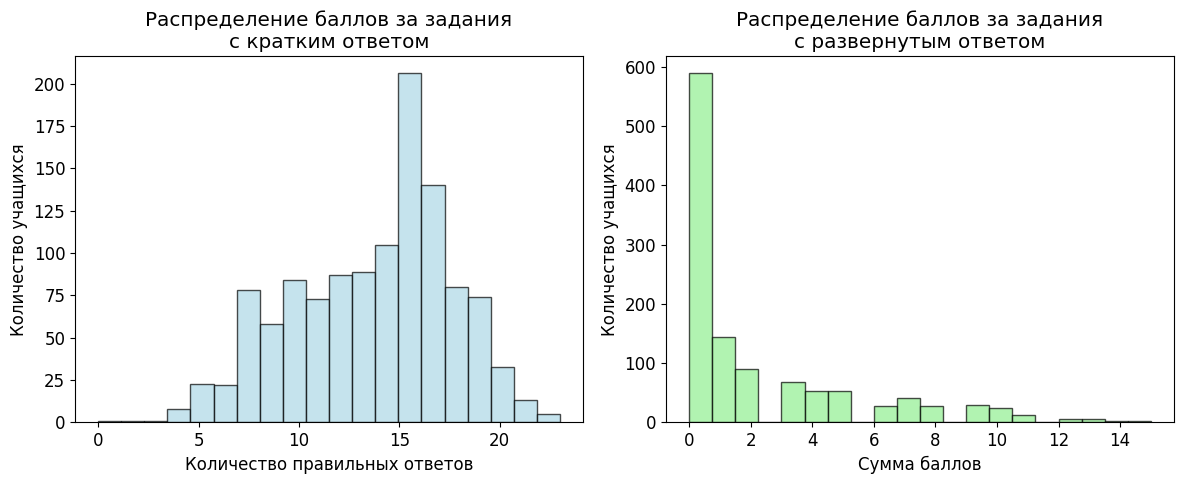


Статистика по заданиям с кратким ответом:
Среднее количество правильных ответов: 13.69
Максимальное количество правильных ответов: 23
Минимальное количество правильных ответов: 0

Статистика по заданиям с развернутым ответом:
Средний балл: 2.17
Максимальный балл: 15
Минимальный балл: 0

Общее количество заданий в экзамене: 15


In [ ]:
print("Пропущенные значения в столбце 'Задания с кратким ответом':", df['Задания с кратким ответом'].isna().sum())
print("Пропущенные значения в столбце 'Задания с развёрнутым ответом':", df['Задания с развёрнутым ответом'].isna().sum())

df['Задания с кратким ответом'] = df['Задания с кратким ответом'].fillna('')
df['Задания с развёрнутым ответом'] = df['Задания с развёрнутым ответом'].fillna('')

short_answer_example = df['Задания с кратким ответом'].iloc[0]
print(f"Пример задания с кратким ответом: {short_answer_example}")

def count_short_answers(answer_string):
    if isinstance(answer_string, str):
        clean_string = answer_string.replace('-', '').replace('+', '')
        return len(clean_string)
    return 0

short_answer_counts = df['Задания с кратким ответом'].apply(count_short_answers)
unique_short_counts = short_answer_counts.unique()

print(f"\nКоличество заданий с кратким ответом: {unique_short_counts[0]}")

long_answer_example = df['Задания с развёрнутым ответом'].iloc[0]
print(f"Пример задания с развернутым ответом: {long_answer_example}")

def count_long_answers(answer_string):
    if isinstance(answer_string, str):
        return answer_string.count('(')
    return 0

long_answer_counts = df['Задания с развёрнутым ответом'].apply(count_long_answers)
unique_long_counts = long_answer_counts.unique()

print(f"Количество заданий с развернутым ответом: {unique_long_counts[0]}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
def calculate_short_score(answer_string):
    if isinstance(answer_string, str):
        return answer_string.count('1') + answer_string.count('+')
    return 0

short_answer_scores = df['Задания с кратким ответом'].apply(calculate_short_score)
plt.hist(short_answer_scores, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
plt.title('Распределение баллов за задания\nс кратким ответом')
plt.xlabel('Количество правильных ответов')
plt.ylabel('Количество учащихся')

plt.subplot(1, 2, 2)
def calculate_long_score(answer_string):
    if isinstance(answer_string, str):
        import re
        scores = re.findall(r'(\d+)\(', answer_string)
        return sum(int(score) for score in scores) if scores else 0
    return 0

long_answer_scores = df['Задания с развёрнутым ответом'].apply(calculate_long_score)
plt.hist(long_answer_scores, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Распределение баллов за задания\nс развернутым ответом')
plt.xlabel('Сумма баллов')
plt.ylabel('Количество учащихся')

plt.tight_layout()
plt.show()

print(f"\nСтатистика по заданиям с кратким ответом:")
print(f"Среднее количество правильных ответов: {short_answer_scores.mean():.2f}")
print(f"Максимальное количество правильных ответов: {short_answer_scores.max()}")
print(f"Минимальное количество правильных ответов: {short_answer_scores.min()}")

print(f"\nСтатистика по заданиям с развернутым ответом:")
print(f"Средний балл: {long_answer_scores.mean():.2f}")
print(f"Максимальный балл: {long_answer_scores.max()}")
print(f"Минимальный балл: {long_answer_scores.min()}")

total_tasks = unique_short_counts[0] + unique_long_counts[0]
print(f"\nОбщее количество заданий в экзамене: {total_tasks}")